In [ ]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf


# my utils
from utils import fa
from utils import modeling
from utils import preprocess_listings
from utils.preprocess_listings import desc_catORnum


# 标准版存档V0：

LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}


def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''


## data

In [2]:
path_df="../data_processed\listings_tactics-paris_london-2306_2312_2406.csv"
df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_22628\2236600794.py:2: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(266852, 121)


In [ ]:
df_all['time']=df_all['time'].astype(str)
df_all['t'] = df_all['time'].map({'2306':0, "2312":1, '2406':2})#***time_trend
df_all['post']=df_all['time'].apply(lambda x : 1 if x=='2406' else 0)
## treatment=post*in_paris

print(df_all[["time","t","in_paris",'post']].value_counts(dropna=False))

df_all.columns.to_list()

time  t  in_paris  post
2406  2  1         1       62738
         0         1       49856
2312  1  0         0       43172
2306  0  0         0       42356
2312  1  1         0       35829
2306  0  1         0       32901
Name: count, dtype: int64


['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [18]:
tactics_bio=[
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"
]
df_all[tactics_bio]=df_all[tactics_bio].fillna(0)
df_all[tactics_bio].isna().value_counts()


ouverture  authenticité  sociabilité  auto_promotion  exemplarité
False      False         False        False           False          266852
Name: count, dtype: int64

In [19]:
df_all['lang'].value_counts()
print(df_all['lang'].value_counts(dropna=False)/len(df_all))
print(df_all['lang_fr'].value_counts(dropna=False))
print(df_all['lang_en'].value_counts(dropna=False))
print(df_all['text_length'].describe())

lang
no_text        0.501821
en             0.362249
fr             0.126197
other_langs    0.009732
Name: count, dtype: float64
lang_fr
0    233176
1     33676
Name: count, dtype: int64
lang_en
0    170185
1     96667
Name: count, dtype: int64
count    266852.000000
mean         31.178567
std          58.485530
min           0.000000
25%           0.000000
50%           0.000000
75%          43.000000
max        1040.000000
Name: text_length, dtype: float64


## no parallel : ONLY PRE!

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
df=df_all.copy()
df=df[df["time"]!="2406"]
print(df.shape)
print(df.time.value_counts(dropna=False))

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  +C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
        "C(time)* in_paris "

)
        # "C(host_picture_type) +"
        # "pic_no_person + pic_pro_style + pic_life_style +"
        # " is_smiling + "
        # "C(age_class) + C(gender) +"
        # "in_paris * in_2024"
        
model_basic=smf.ols(formula, data=df).fit()
summary=model_basic.summary()
print(summary)
# C(time)* in_paris 交互项显著说明pre时候london& paris发展趋势已经不同了
# 平行发展趋势不成立（否则C(time)* in_paris 中会混杂jo和已有的影响）


(154258, 122)
time
2312    79001
2306    75257
Name: count, dtype: int64
                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     3399.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:18:54   Log-Likelihood:                 36694.
No. Observations:              154258   AIC:                        -7.333e+04
Df Residuals:                  154227   BIC:                        -7.302e+04
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

## tactic~ vars

In [112]:
df=df_all.copy()
df_plot=df.groupby(['in_paris',"time"])[tactics_bio].mean().reset_index()
display(df_plot)

df_plot=df.groupby(['in_paris',"time"])['booking_rate_l90d'].mean().reset_index()
display(df_plot)



,in_paris,time,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,0,2306,-0.111349,-0.181066,-0.056410,0.188441,0.030553
1,0,2312,-0.111726,-0.204839,-0.082297,0.207675,0.037917
2,0,2406,-0.113564,-0.216109,-0.088271,0.214976,0.038187
3,1,2306,-0.093083,-0.158274,-0.044763,0.097293,0.044539
4,1,2312,-0.083193,-0.155755,-0.053823,0.093660,0.023148
5,1,2406,-0.088205,-0.144402,-0.060383,0.103216,0.030036


,in_paris,time,booking_rate_l90d
0,0,2306,0.162585
1,0,2312,0.072095
2,0,2406,0.119446
3,1,2306,0.213811
4,1,2312,0.102370
5,1,2406,0.076108


In [ ]:
importlib.reload(modeling)
from utils.modeling import write_formula,build_model
import statsmodels.api as sm
import statsmodels.formula.api as smf

    
x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", "has_rating", "number_of_reviews_ltm",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", 
    "text_length",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
]  

tactics_bio=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
tactics_pic=["host_picture_type","is_smiling"]
group_vars=["in_paris","in_2024"]


# -----mod-----
df=df_all.copy()
formula= (" auto_promotion ~ C(host_identity_verified)  + review_scores_rating + has_rating + number_of_reviews_ltm +"
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate + C(host_response_time)+ "
            "has_text + lang_fr + lang_en + text_length +"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "in_paris * C(time) "
            # 每个时间点的差异都独立估计; 2312交互显著说明pre_trend不平行，2406交互显著
          
            # "t * in_paris +post * in_paris"# C(time)
            # 线性趋势，简化假设
)
model=smf.ols(formula, data=df).fit(cov_type="HC1")#robust standard errors

print(model.summary())

# JO effect =“post period（2406） vs pre period（2312） 的 DiD变化”(DDD)

## in_paris:C(time)[T.2406]jo期间差异-in_paris:C(time)[T.2312]普通差异=JO真实差异

                            OLS Regression Results                            
Dep. Variable:         auto_promotion   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     2288.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:09:13   Log-Likelihood:            -2.4809e+05
No. Observations:              266852   AIC:                         4.962e+05
Df Residuals:                  266824   BIC:                         4.965e+05
Df Model:                          27                                         
Covariance Type:                  HC1                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

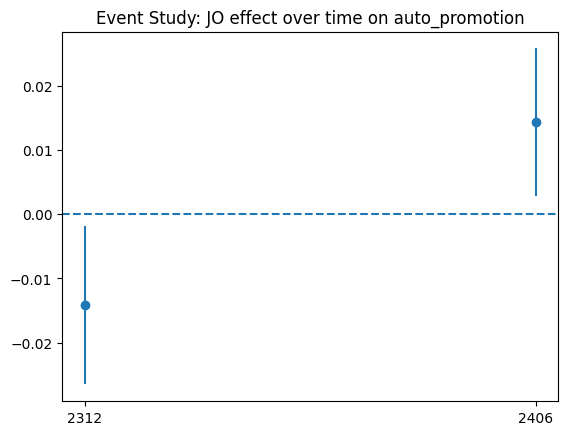

In [ ]:
import statsmodels.formula.api as smf
import numpy as np


def run_model(df, y):
    formula = f"""
    {y} ~ C(host_identity_verified) + review_scores_rating + has_rating +
    number_of_reviews_ltm + C(host_is_superhost) +
    years_since_host + professional_host +
    host_response_rate + C(host_response_time) +
    has_text + lang_fr + lang_en + text_length +
    price + availability_90 + C(room_type) + C(instant_bookable) +
    in_paris * C(time)
    """
    model = smf.ols(formula, data=df).fit()
    return model

tactic="auto_promotion"
model=run_model(df, y=tactic)
coefs = model.params.filter(like="in_paris:C(time)")
ses = model.bse.filter(like="in_paris:C(time)")


import matplotlib.pyplot as plt
times = ["2312", "2406"]
coef = [coefs[f"in_paris:C(time)[T.{t}]"] for t in times]
se = [ses[f"in_paris:C(time)[T.{t}]"] for t in times]
plt.errorbar(times, coef, yerr=1.96*np.array(se), fmt='o')
plt.axhline(0, linestyle='--')
plt.title(f"JO effect over time on {tactic}")
plt.show()


# event study 直接估计“每个时间点相对于基期的 treatment effect”
# Effectt​=(Paris−London)t​−(Paris−London)base​
# | 时间   | 系数      | 含义                     |
# | ---- | ------- | ---------------------- |
# | 2312 | -0.0142 | JO前 Paris vs London 差异 |
# | 2406 | +0.0144 | JO期间 effect            |


In [ ]:
tactics = ["ouverture", "authenticité", "sociabilité", "auto_promotion", "exemplarité"]
results = []

for y in tactics:
    print(y)
    model = run_model(df, y)
    for t in ["2312", "2406"]:
        coef = model.params[f"in_paris:C(time)[T.{t}]"]
        se = model.bse[f"in_paris:C(time)[T.{t}]"]

        results.append({
            "tactic": y,
            "time": t,
            "coef": coef,
            "ci_low": coef - 1.96*se,
            "ci_high": coef + 1.96*se,
            "sig": "*" if abs(coef/se) > 1.96 else ""
        })

ouverture
authenticité
sociabilité
auto_promotion
exemplarité


,tactic,time,coef,ci_low,ci_high,sig
0,ouverture,2312,0.005668,-0.006977,0.018313,
1,ouverture,2406,0.001713,-0.010052,0.013477,
2,authenticité,2312,0.029654,0.016556,0.042753,*
3,authenticité,2406,0.043697,0.031511,0.055884,*
4,sociabilité,2312,0.022324,0.008787,0.035861,*
5,sociabilité,2406,0.034783,0.022189,0.047377,*
6,auto_promotion,2312,-0.014188,-0.026529,-0.001847,*
7,auto_promotion,2406,0.014376,0.002894,0.025857,*
8,exemplarité,2312,-0.020017,-0.033129,-0.006905,*
9,exemplarité,2406,0.004475,-0.007724,0.016674,


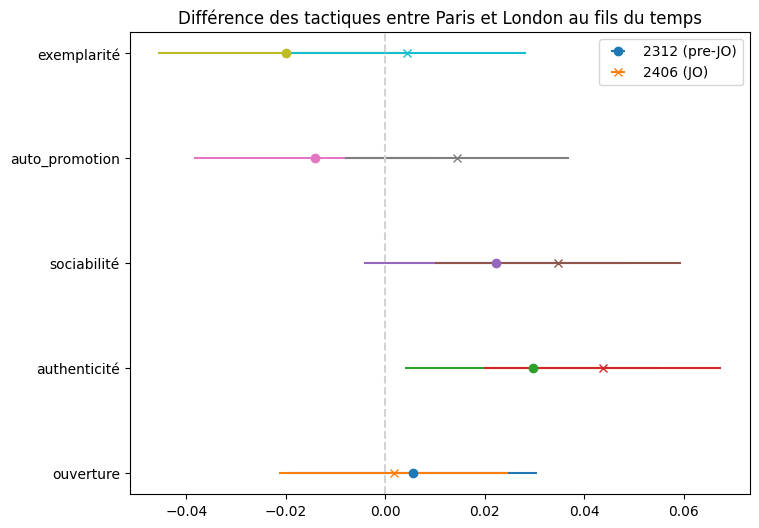

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = pd.DataFrame(results)
tactics = ["ouverture", "authenticité", "sociabilité", "auto_promotion", "exemplarité"]
# df_plot["tactic"] = pd.Categorical(
#     df_plot["tactic"],
#     categories=tactics,
#     ordered=True
# )
# df_plot = df_plot.sort_values("tactic")

display(df_plot)
fig, ax = plt.subplots(figsize=(8,6))

# for i, tactic in enumerate(tactics):
#     sub = df_plot[df_plot["tactic"] == tactic]
    
#     ax.errorbar(
#         sub["coef"],
#         [i]*len(sub),
#         xerr=1.96*(sub["ci_high"]-sub["coef"]),
#         fmt="o",
#         label=tactic
#     )


for i, tactic in enumerate(tactics):
    sub = df_plot[df_plot["tactic"] == tactic]
    for _, row in sub.iterrows():

        marker = 'x' if row["time"] == "2406" else 'o'

        ax.errorbar(
            row["coef"],
            i,
            xerr=1.96 * (row["ci_high"] - row["coef"]),
            fmt=marker,
            label=row["time"] if i == 0 else ""
        )

ax.legend(["2312 (pre-JO)", "2406 (JO)"])

ax.axvline(0, linestyle="--", color='lightgray')
ax.set_yticks(range(len(tactics)))
ax.set_yticklabels(tactics)
ax.set_title("Différence des tactiques entre Paris et London au fils du temps")

plt.show()

In [ ]:
def extract_jo_effect(model):
    b1 = model.params['in_paris:C(time)[T.2406]']
    b0 = model.params['in_paris:C(time)[T.2312]']
    
    se1 = model.bse['in_paris:C(time)[T.2406]']
    se0 = model.bse['in_paris:C(time)[T.2312]']
    
    effect = b1 - b0
    
    # 简化 delta method（保守）
    se = (se1**2 + se0**2) ** 0.5
    
    return effect, se

In [ ]:
tactics = ['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']

results = []

for y in tactics:
    print
    model = run_model(df_all, y)
    effect, se = extract_jo_effect(model)
    
    results.append({
        'variable': y,
        'coef': effect,
        'se': se,
        'ci_low': effect - 1.96*se,
        'ci_high': effect + 1.96*se
    })

ouverture
authenticité
sociabilité
auto_promotion
exemplarité


,variable,coef,se,ci_low,ci_high
0,ouverture,-0.003955,0.008812,-0.021227,0.013316
1,authenticité,0.014043,0.009128,-0.003848,0.031934
2,sociabilité,0.012459,0.009433,-0.006030,0.030949
3,auto_promotion,0.028564,0.008600,0.011707,0.045420
4,exemplarité,0.024492,0.009137,0.006583,0.042401


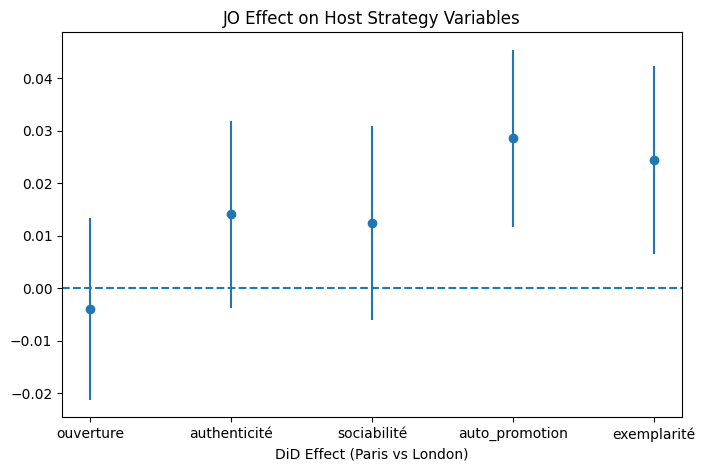

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

res = pd.DataFrame(results)
display(res)

plt.figure(figsize=(8,5))

plt.errorbar(
    res['variable'],
    res['coef'],
    yerr=1.96*res['se'],
    fmt='o'
)

plt.axhline(0, linestyle='--')

plt.title("JO Effect on Host Strategy Variables")
plt.xlabel("DiD Effect (Paris vs London)")
plt.show()

# 巴黎在2406JO期间 与伦敦的“策略使用变化差异”，去掉了2312的差异（作为基准差异）



## bookingrate ~vars

In [ ]:
df=df_all.copy()

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  +C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
        "in_paris * C(time)"
        # "C(host_picture_type) +"
        # "pic_no_person + pic_pro_style + pic_life_style +"
        # " is_smiling + "
        # "C(age_class) + C(gender) +"
    
)

model_basic=smf.ols(formula, data=df).fit()
summary=model_basic.summary()
print(summary)

"""
2306到2312巴黎比伦敦度多下降了 in_paris:C(time)[T.2312]，-0.0304，从2306到2406多下降了in_paris:C(time)[T.2406] -0.0579 ，
如果没有 JO，Paris 应该延续 2306→2312 的趋势(in_paris:C(time)[T.2312]，-0.0304)
所以 JO effect = −0.0579 − (−0.0304) = −0.0275
"""

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     5530.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:19:16   Log-Likelihood:                 88253.
No. Observations:              266852   AIC:                        -1.764e+05
Df Residuals:                  266819   BIC:                        -1.761e+05
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

'\n2306到2312巴黎比伦敦度多下降了 in_paris:C(time)[T.2312]，-0.0304，从2306到2406多下降了in_paris:C(time)[T.2406] -0.0579 ，\n如果没有 JO，Paris 应该延续 2306→2312 的趋势(in_paris:C(time)[T.2312]，-0.0304)\n所以 JO effect = −0.0579 − (−0.0304) = −0.0275\n'

In [85]:
# print(df_all.booking_rate_l90d.describe())
# print(df_all['group'].value_counts(dropna=False))
# df_all.groupby(['time','in_paris'])['booking_rate_l90d'].describe()

city,time,London,Paris,Paris_cf
0,2306,0.162585,0.213811,0.213811
1,2312,0.072095,0.102370,0.102370
2,2406,0.119446,0.076108,0.149720


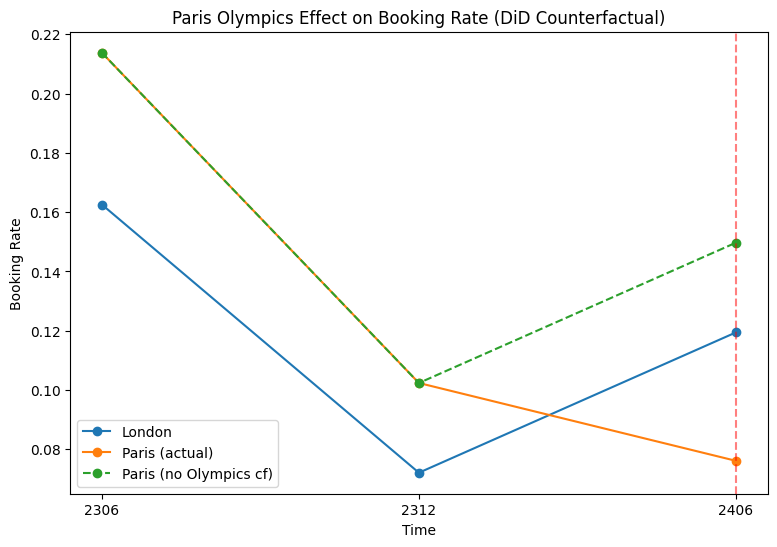

In [ ]:

# Paris2406cf​=Paris2312 ​+(London2406​−London2312​)


import pandas as pd
trend = df_all.groupby(['time', 'in_paris'])['booking_rate_l90d'].mean().reset_index()

trend['city'] = trend['in_paris'].map({1: 'Paris', 0: 'London'})
pivot = trend.pivot(index='time', columns='city', values='booking_rate_l90d').reset_index()

pivot['Paris_cf'] = pivot['Paris']  # 初始化

# 只改 2406（奥运期）
trend_london_change = pivot.loc[pivot['time']=='2406','London'].values[0] - \
                      pivot.loc[pivot['time']=='2312','London'].values[0]

pivot.loc[pivot['time']=='2406','Paris_cf'] = \
    pivot.loc[pivot['time']=='2312','Paris'].values[0] + trend_london_change
display(pivot)




import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))

# London
plt.plot(pivot['time'], pivot['London'], marker='o', label='London')

# Paris actual
plt.plot(pivot['time'], pivot['Paris'], marker='o', label='Paris (actual)')

# Paris counterfactual
plt.plot(pivot['time'], pivot['Paris_cf'], marker='o', linestyle='--', label='Paris (no Olympics cf)')

# 奥运时间标记
plt.axvline(x='2406', linestyle='--', color='red', alpha=0.5)

plt.title("Paris Olympics Effect on Booking Rate (DiD Counterfactual)")
plt.ylabel("Booking Rate")
plt.xlabel("Time")
plt.legend()
plt.show()
# 画图是描述性的不需要因果识别


## interaction

In [142]:
df=df_all.copy()
formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  +C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        
        # "C(host_picture_type) +"
        # "pic_no_person + pic_pro_style + pic_life_style +"
        # " is_smiling + "
        # "C(age_class) + C(gender) +"
        # "in_paris * C(time)"
        # "C(time)+ t * in_paris +"
        "(ouverture + authenticité + sociabilité + auto_promotion + exemplarité)* C(time) * in_paris"
)

model_interaction=smf.ols(formula, data=df).fit()
print(model_interaction.summary())



                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.400
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     3127.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:45:04   Log-Likelihood:                 88638.
No. Observations:              266852   AIC:                        -1.772e+05
Df Residuals:                  266794   BIC:                        -1.766e+05
Df Model:                          57                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [145]:
## 每一组的真实effect
import numpy as np
import pandas as pd
from itertools import product
  
    
def get_did_marginal_effect(
    model, 
    key_var,
    paris_var="in_paris",
    time_var="C(time)[T.2406]"
):
    """
    每组中，叠加的真实效应
    """
    params = model.params
    param_names = params.index.tolist()

    rows = []

    # 四种组合
    for p, t in product([0,1], [0,1]): #***
        # 用0,1标注出我们要交互的vars的index:
        lin_comb = np.zeros(len(params))
        # 主效应
        if key_var in param_names:
            lin_comb[param_names.index(key_var)] = 1

        # key_var × paris
        term = f"{key_var}:{paris_var}"
        if term in param_names:
            lin_comb[param_names.index(term)] = p

        # key_var × time
        term = f"{key_var}:{time_var}"
        if term in param_names:
            lin_comb[param_names.index(term)] = t

        # triple interaction
        term = f"{key_var}:{paris_var}:{time_var}"
        if term in param_names:
            lin_comb[param_names.index(term)] = p * t
        # print(lin_comb)
        
        # t-test
        t_res = model.t_test(lin_comb)
        # print(t_res)
        rows.append({
            "in_paris": p,
            "time": t,
            "group": f"{'Paris' if p ==1 else 'London'} {'2406' if t ==1 else '2306'}",
            "coef": float(t_res.effect),
            "se": float(t_res.sd),
            "t": float(t_res.tvalue),
            "pval": float(t_res.pvalue),
            "sig": p_to_sig(float(t_res.pvalue)),            
        })
    result_df= pd.DataFrame(rows)
    result_df['label']=result_df['group']+' '+result_df['sig']
    
    return result_df

res = get_did_marginal_effect(model=model_interaction, key_var="auto_promotion", paris_var="in_paris", time_var="C(time)[T.2406]")
display(res)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_22628\953474180.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "coef": float(t_res.effect),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_22628\953474180.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "se": float(t_res.sd),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_22628\953474180.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "t": float(t_res.tvalue),


,in_paris,time,group,coef,se,t,pval,sig,label
0,0,0,London 2306,-0.009837,0.001435,-6.853133,7.240543e-12,***,London 2306 ***
1,0,1,London 2406,-0.003731,0.001382,-2.699922,6.936018e-03,**,London 2406 **
2,1,0,Paris 2306,-0.019996,0.001831,-10.922757,9.095434e-28,***,Paris 2306 ***
3,1,1,Paris 2406,-0.013890,0.002675,-5.192383,2.077716e-07,***,Paris 2406 ***


In [147]:

# ---------- 收集所有结果 ----------
all_results = []
for var in tactics:
    print(var)
    res = get_did_marginal_effect(model=model_interaction, key_var=var, paris_var="in_paris", time_var="C(time)[T.2406]")
    res["tactic"] = var
    all_results.append(res)
    # break
all_results_df=pd.concat(all_results, ignore_index=True)
all_results_df=all_results_df.sort_values(['tactic','in_paris','time'])

#整理顺序
all_results_df = (
    all_results_df
    .assign(tactic=pd.Categorical(all_results_df["tactic"], categories=tactics, ordered=True))
    .sort_values("tactic")
    .reset_index(drop=True)
)
display(all_results_df)

ouverture
authenticité
sociabilité
auto_promotion
exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_22628\953474180.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "coef": float(t_res.effect),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_22628\953474180.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "se": float(t_res.sd),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_22628\953474180.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "t": float(t_res.tvalue),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_22628\95

,in_paris,time,group,coef,se,t,pval,sig,label,tactic
0,1,1,Paris 2406,-0.003089,0.002670,-1.156872,2.473258e-01,,Paris 2406,ouverture
1,1,0,Paris 2306,-0.005187,0.001727,-3.002898,2.674470e-03,**,Paris 2306 **,ouverture
2,0,1,London 2406,0.002860,0.001406,2.034497,4.190252e-02,*,London 2406 *,ouverture
3,0,0,London 2306,0.000762,0.001472,0.517414,6.048679e-01,,London 2306,ouverture
4,0,0,London 2306,0.011661,0.001477,7.897068,2.866168e-15,***,London 2306 ***,authenticité
5,0,1,London 2406,0.004097,0.001402,2.921393,3.484990e-03,**,London 2406 **,authenticité
6,1,0,Paris 2306,0.016470,0.001724,9.550610,1.299657e-21,***,Paris 2306 ***,authenticité
7,1,1,Paris 2406,0.008906,0.002661,3.346507,8.184799e-04,***,Paris 2406 ***,authenticité
8,0,1,London 2406,0.005650,0.001308,4.319328,1.565618e-05,***,London 2406 ***,sociabilité
9,0,0,London 2306,0.010800,0.001375,7.854533,4.027453e-15,***,London 2306 ***,sociabilité


['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']


C:\Users\yeliu\AppData\Local\Temp\ipykernel_22628\3053138115.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


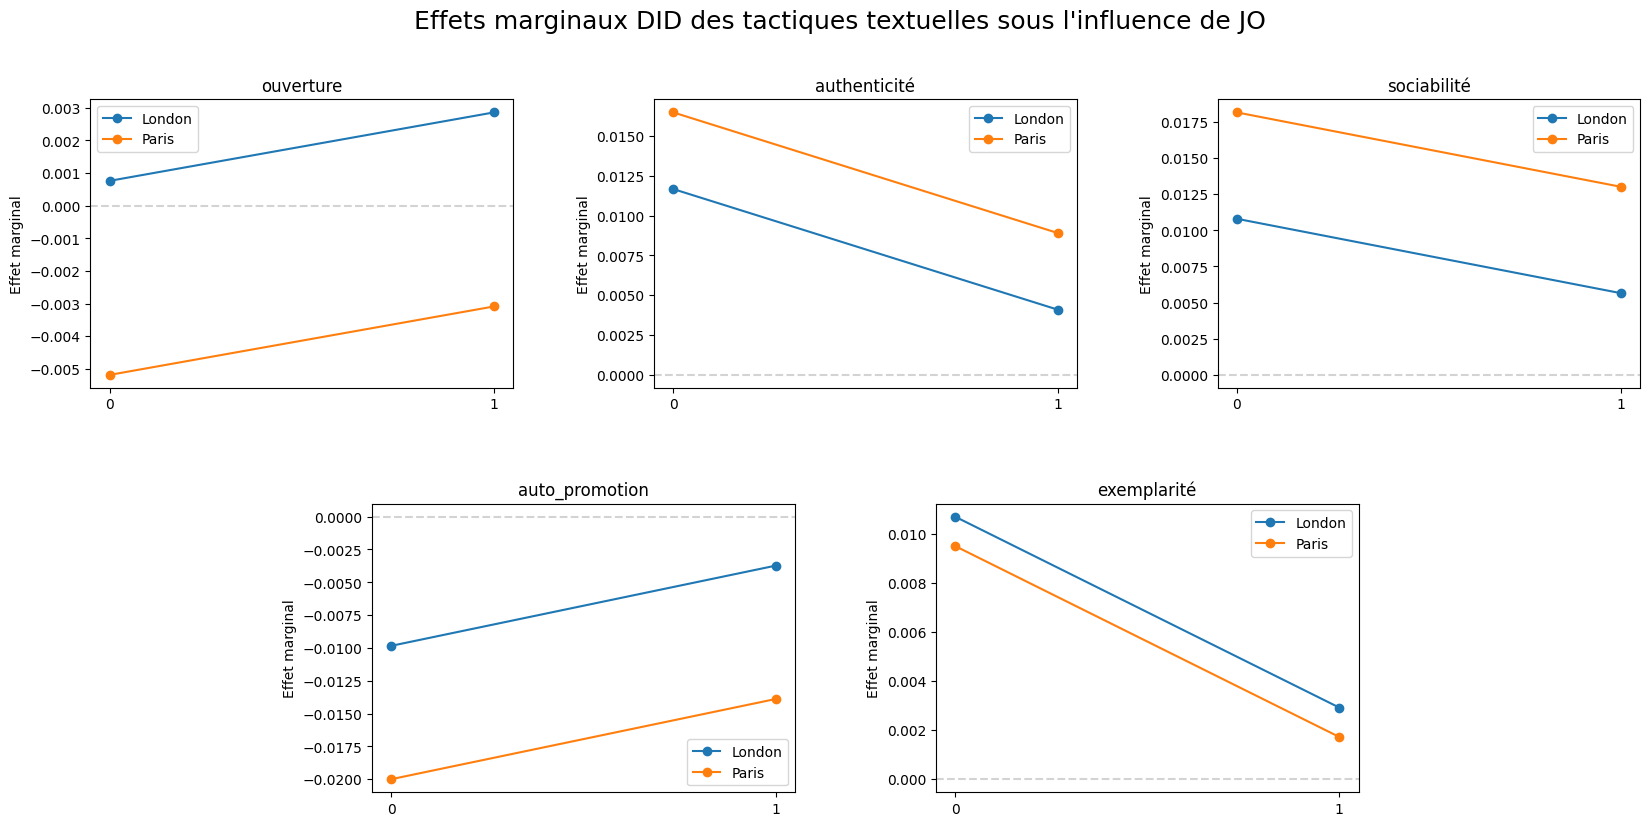

In [153]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

## VIS2: DID 解释因果,策略效果有没有变化
# ps. did可视化，观察不同组效果的差异，而不是一个策略从0-1对于预订率的影响趋势（这种情况采用predict）

plot_df=all_results_df.copy()
tactics_vars=tactics_bio
print(tactics_vars)

# =['ouverture',"authenticité", 'sociabilité', "auto_promotion","exemplarité"]

# --------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_vars), len(axes))


# ---groups---    
group_labels = ["London 2306", "London 2312", "London 2406", "Paris 2306", "Paris 2312","Paris 2406"]

for i, tactic in enumerate(tactics_vars):
    ax = axes[i]
    sub = plot_df[plot_df["tactic"] == tactic].sort_values(["in_paris","time"])
    # did_sig=results_did_df[(results_did_df['tactic']==tactic)&(results_did_df["type"]=="DID")]['sig'].iloc[0]

    london = sub[sub["in_paris"]==0]
    ax.plot(
        london["time"],
        london["coef"],
        marker='o',
        label="London"
    )
    # Paris
    paris = sub[sub["in_paris"]==1]
    ax.plot(
        paris["time"],
        paris["coef"],
        marker='o',
        label="Paris"
    )
    
    ax.set_xticks([0,1])
    # ax.set_xticklabels(["2306", "2312", "2406"], rotation=20)
    ax.set_title(f"{tactic}")#  {did_sig}
    ax.set_ylabel("Effet marginal")
    ax.axhline(y=0, color='lightgray', linestyle='--')

    ax.legend()

fig.suptitle(
        "Effets marginaux DID des tactiques textuelles sous l'influence de JO",
        fontsize=18,
        y=0.98
    )
# ---------- 调整布局（让第二行居中） ----------
plt.legend()
plt.tight_layout()
plt.show()

##标注斜率是否显著？？
## ouverture, exemplarité的效果没有jo很大影响，和london同趋势发展
# auth和socio被压制
# promo上升
